# Aims of this Notebook:
- Exploratory Data Analysis
    - Check Data Formats
    - Identify Malformed Inputs
    - Trends, Patterns, Anomalies
- Plans for constructing a forecasting model for a vessel's next location
    - How the data might be transformed
    - Experimentations with input featues

# Exploratory Data Analysis

## Loading Datasets

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.basemap import Basemap

In [2]:
# Read all the datasets:
port_calls = pd.read_csv("port_calls.csv")
vessels = pd.read_csv("vessels.csv")
trades = pd.read_csv("trades.csv")

In [3]:
port_calls.head()

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
0,366999220,74064,2023-01-01 00:00:36.000,2023-01-01 16:02:18.000,111617,5.5,Novorossiysk,37.813008,44.718040
1,366974831,70585,2023-01-01 00:00:48.000,2023-01-01 15:16:55.000,0,-0.2,Singapore,103.745613,1.234135
2,367187709,90771,2023-01-01 00:01:00.000,2023-01-03 00:00:00.000,0,-5.5,Philadelphia,-75.229059,39.949923
3,366902380,86336,2023-01-01 00:02:19.000,2023-01-03 13:37:40.000,0,-4.7,Sao Luis,-44.380646,-2.605307
4,366971646,105430,2023-01-01 00:02:57.000,2023-01-02 01:31:40.000,0,-2.0,Ulsan,129.332479,35.479874


In [4]:
vessels.head()

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
0,80439,Active,In Service/Commission,China,2010.0,Marshall Islands,156717,Crude/Oil Products Tanker
1,114128,Active,In Service/Commission,Japan,1998.0,Sierra Leone,5790,Products Tanker
2,70991,Active,In Service/Commission,United States of America,2004.0,United States of America,141740,Crude/Oil Products Tanker
3,83934,Active,In Service/Commission,South Korea,2011.0,Greece,319861,Crude Oil Tanker
4,79383,Active,In Service/Commission,South Korea,2008.0,Malta,50344,Crude/Oil Products Tanker


In [5]:
trades.head()

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
0,19953452,370515046,370587079.0,260.0,1342175.0,2023-11-01 17:10:00.000,2023-11-08 12:30:00.000,palm fatty acid distillate,chem/bio
1,19322180,370515046,370634751.0,4551.0,1836735.0,2023-11-01 17:10:00.000,2023-11-10 01:46:00.000,palm fatty acid distillate,chem/bio
2,19953448,370515046,370811312.0,170.0,2714319.0,2023-11-01 17:10:00.000,2023-11-20 22:53:28.000,palm fatty acid distillate,chem/bio
3,19284088,370574938,370587079.0,1658.0,1197777.0,2023-11-04 23:30:00.000,2023-11-08 12:30:00.000,used cooking oil,chem/bio
4,19339728,370739975,370811312.0,11234.0,101991.0,2023-11-18 17:35:25.000,2023-11-20 22:53:28.000,chem/bio,chem/bio


In [6]:
print("Dataset shapes:")
print("Missing port calls:", port_calls.shape)
print("Missing vessels:", vessels.shape)
print("Missing trades:", trades.shape)

Dataset shapes:
Missing port calls: (347277, 9)
Missing vessels: (8901, 8)
Missing trades: (240037, 9)


### Some Initial Thoughts
- Could be worth transforming date columns from strings into datetime objects
- Can convert some columns into categorical types - but worth seeing how many categories there are for these

## Malformed Inputs

This section involves first converting date columns, then looking for missing values, miscalculated, or impossible values

In [7]:
# Convert the date columns to datetime format
port_calls["start_utc"] = pd.to_datetime(port_calls["start_utc"])
port_calls["end_utc"] = pd.to_datetime(port_calls["end_utc"])

trades["start_date_time"] = pd.to_datetime(trades["start_date_time"])
trades["end_date_time"] = pd.to_datetime(trades["end_date_time"])

### Missing Values

#### Port Calls

In [8]:
# Missing values
print("Missing values in port_calls:")
port_calls.isnull().sum()

Missing values in port_calls:


id                           0
vessel_id                    0
start_utc                    0
end_utc                     24
cargo_volume                 0
draught_change           49271
destination                  0
destination_longitude     1018
destination_latitude      1018
dtype: int64

In [9]:
# Starting with end_utc - there are 24 rows where values are missing - worth seeing if these are missing anything else or have any common characteristics
missing_end_utc = port_calls[port_calls["end_utc"].isnull()]
missing_end_utc

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
22419,367213090,115267,2023-01-24 21:12:05,NaT,0,-2.0,Kaohsiung,120.334623,22.511660
50050,367498482,62621,2023-02-22 14:01:53,NaT,90794,NaN,Mumbai,72.959474,18.872354
91102,367893216,69124,2023-04-06 03:33:00,NaT,0,NaN,Chittagong,91.801556,22.054577
126285,368342536,101735,2023-05-12 09:00:00,NaT,0,NaN,Genoa,8.879961,44.412879
145494,368607998,115833,2023-06-01 09:36:55,NaT,11814,NaN,Chornomorsk,30.665153,46.315711
164383,368795374,114750,2023-06-21 11:26:53,NaT,0,0.0,Nishtun,52.203412,15.816707
187548,369270269,75766,2023-07-15 20:52:17,NaT,326360,NaN,Port Gentil,8.731685,-0.636293
196664,369412092,114266,2023-07-25 08:05:21,NaT,0,NaN,Khalifa Industrial Zone,54.675400,24.819881
215085,369653146,116735,2023-08-14 03:48:10,NaT,0,NaN,Surabaya,112.688849,-7.168280
222781,369762149,68285,2023-08-22 01:59:45,NaT,0,NaN,Himeji,134.737559,34.769154


These port calls dont seem to have much in common, aside also missing draught change - Could just be missed recordings?

Worth plotting them anyway to check for regions (harder to tell vs looking purely at lon/lat)

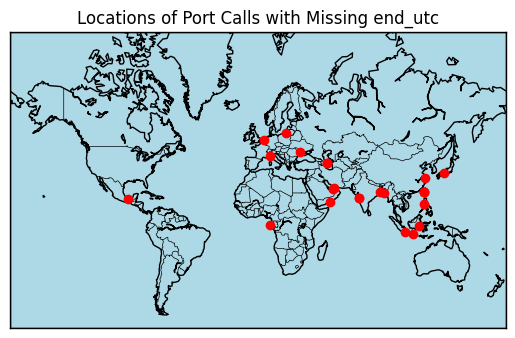

In [10]:
# Check to see how these are distributed geographically - are they all in one area or spread out?
missing_end_utc_map = Basemap(
    projection="merc",
    llcrnrlat=-60,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution="c",
)
missing_end_utc_map.drawcoastlines()
missing_end_utc_map.drawcountries()
missing_end_utc_map.drawmapboundary(fill_color="lightblue")
x, y = missing_end_utc_map(
    missing_end_utc["destination_longitude"].values,
    missing_end_utc["destination_latitude"].values,
)
missing_end_utc_map.scatter(x, y, marker="o", color="red", zorder=5)
plt.title("Locations of Port Calls with Missing end_utc")
plt.show()

Plot shows values spread mostly through Asia, with only a few outside this region - Likely some issue with recording

In [11]:
# Missing Draught Change - 49271 missing values (~14% of the dataset) - worth seeing if these are missing anything else or have any common characteristics
missing_draught_change = port_calls[port_calls["draught_change"].isnull()]
missing_draught_change

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude
10,366603362,82485,2023-01-01 00:07:35,2023-01-02 01:00:00,12444,NaN,Kawasaki,139.752629,35.494882
11,366999241,68950,2023-01-01 00:08:53,2023-01-01 14:26:17,29310,NaN,Ulsan,129.332479,35.479874
27,368468278,69430,2023-01-01 00:33:00,2023-01-06 06:35:00,0,NaN,Caofeidian,118.497186,39.010958
31,366999245,79699,2023-01-01 00:36:00,2023-01-01 05:34:00,0,NaN,Baku,49.889961,40.343447
38,366952350,82251,2023-01-01 00:52:15,2023-01-01 23:57:01,5625,NaN,Bordeaux,-0.597965,45.046788
...,...,...,...,...,...,...,...,...,...
347233,371324045,72634,2023-12-31 22:38:10,2024-01-01 23:45:03,28708,NaN,Constanta Light.,28.994348,43.987877
347234,371324044,71444,2023-12-31 22:38:10,2024-01-01 23:45:03,51803,NaN,Constanta Light.,28.994348,43.987877
347272,371325310,72072,2023-12-31 23:56:57,2024-01-01 03:37:33,6845,NaN,Kerch Light.,36.565590,45.105042
347273,371325316,72072,2023-12-31 23:56:58,2024-01-01 03:28:16,11051,NaN,Kerch Light.,36.565590,45.105042


In [12]:
missing_draught_change.isnull().sum()

id                           0
vessel_id                    0
start_utc                    0
end_utc                     17
cargo_volume                 0
draught_change           49271
destination                  0
destination_longitude      153
destination_latitude       153
dtype: int64

Mostly just that column missing for these

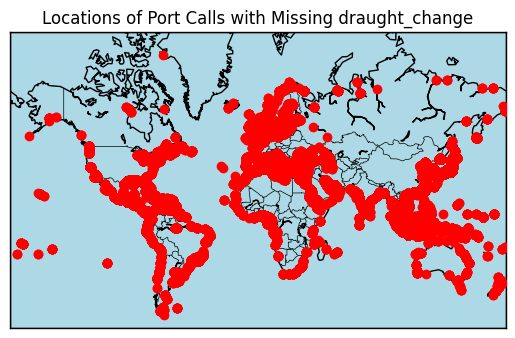

In [13]:
# Worth Plotting these too
missing_draught_change_map = Basemap(
    projection="merc",
    llcrnrlat=-60,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    resolution="c",
)
missing_draught_change_map.drawcoastlines()
missing_draught_change_map.drawcountries()
missing_draught_change_map.drawmapboundary(fill_color="lightblue")
x, y = missing_draught_change_map(
    missing_draught_change["destination_longitude"].values,
    missing_draught_change["destination_latitude"].values,
)
missing_draught_change_map.scatter(x, y, marker="o", color="red", zorder=5)
plt.title("Locations of Port Calls with Missing draught_change")
plt.show()

These are well distributed, and a missing 'draught_change' isn't the worst field to be missing

In [14]:
# Assuming Missing values for 'destination_longitude' and 'destination_latitude' appear as a pair
missing_location = port_calls[
    port_calls["destination_longitude"].isnull()
    & port_calls["destination_latitude"].isnull()
]
len(missing_location)

1018

This confirms that they always occur as a pair

Given we are never missing a destination (str) we can look for any similarities

In [15]:
locations = missing_location.destination.value_counts()
locations.head(10)

destination
Iran                                 870
Offshore Venezuela (West of Suez)     41
Philippines                           20
Offshore Middle East Gulf             20
North East Atlantic Ocean             18
China                                  4
Malaysia                               4
Asia                                   3
Russian Federation                     3
Vietnam                                2
Name: count, dtype: int64

Most of the points within this being made up by Iran makes sense, vessels may turn off/spoff AIS information or it could be that data gathering in the region is hard

The two offshore destinations, and the North East Atlantic Ocean missing values could be explained by those regions being too large to assign single lat,long pairs to.

The overarching theme with these destinations, compared to the normal is the lack of specific port names or locations, instead defaulting to using more generic locations


Missing Locations Number of Port Calls
mean: 19.325147347740668
median: 16.0
minimum: 1
maximum: 143


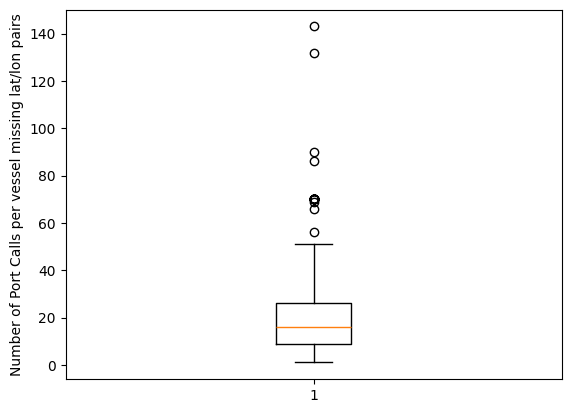

In [16]:
# Missing Locations
# What is the distribution of number of port calls these vesels have
values = []
for _, row in missing_location.iterrows():
    matched_rows = port_calls[port_calls["vessel_id"] == row.vessel_id]
    values.append(len(matched_rows))

mean = np.mean(values)
median = np.median(values)
minimum = np.min(values)
maximum = np.max(values)

print("Missing Locations Number of Port Calls")
print(f"mean: {mean}")
print(f"median: {median}")
print(f"minimum: {minimum}")
print(f"maximum: {maximum}")

plt.boxplot(values)
plt.ylabel("Number of Port Calls per vessel missing lat/lon pairs")
plt.show()

#### Vessels

In [17]:
print("Missing values in vessels:")
vessels.isnull().sum()

Missing values in vessels:


id                 0
status             0
status_detail      0
build_country    114
build_year         1
flag_name         25
dead_weight        0
vessel_type        0
dtype: int64

~1.6% of vessels have missing information

In [18]:
# Starting with build country
missing_build_country = vessels[vessels["build_country"].isnull()]
missing_build_country

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
6,118651,Active,In Service/Commission,NaN,2021.0,NaN,7356,Chemical/Oil Products Tanker
30,59155,Active,In Service/Commission,NaN,1979.0,United States of America,352,Crude/Oil Products Tanker
43,116991,Active,In Service/Commission,NaN,1998.0,Japan,1417,Asphalt/Bitumen Tanker
44,116996,Active,In Service/Commission,NaN,2013.0,China Peoples's Republic,3200,Asphalt/Bitumen Tanker
55,116979,Active,In Service/Commission,NaN,1995.0,Indonesia,1354,Asphalt/Bitumen Tanker
...,...,...,...,...,...,...,...,...
5221,82053,Active,In Service/Commission,NaN,2010.0,United States of America,1584,Crude/Oil Products Tanker
5241,88370,Active,In Service/Commission,NaN,2010.0,United States of America,428,Crude/Oil Products Tanker
5300,119517,Active,In Service/Commission,NaN,2021.0,Turkey,6043,Chemical/Oil Products Tanker
5312,63637,Active,In Service/Commission,NaN,2004.0,United States of America,334,Crude/Oil Products Tanker


A lot of these vessels seem to be missing a flag too - Worth totalling these to see if all our missing values come from these 114 vessels

In [19]:
missing_build_country.isnull().sum()

id                 0
status             0
status_detail      0
build_country    114
build_year         1
flag_name         16
dead_weight        0
vessel_type        0
dtype: int64

Most of them are in this subset but there are 9 vessels not within this set

In [20]:
# They are
remaining_vessels = vessels[~vessels.id.isin(missing_build_country.id)]
remaining_missing_flag = remaining_vessels[remaining_vessels["flag_name"].isnull()]
remaining_missing_flag

,id,status,status_detail,build_country,build_year,flag_name,dead_weight,vessel_type
1148,116686,Active,In Service/Commission,China,2007.0,NaN,4400,Asphalt/Bitumen Tanker
1521,116613,Active,In Service/Commission,South Korea,2020.0,NaN,25039,Chemical/Oil Products Tanker
3001,118616,Active,In Service/Commission,China,2021.0,NaN,5500,Chemical/Oil Products Tanker
3652,118485,Active,In Service/Commission,Japan,2023.0,NaN,26300,Chemical/Oil Products Tanker
4755,117178,Active,In Service/Commission,Japan,2022.0,NaN,25160,Chemical/Oil Products Tanker
5299,117205,Active,In Service/Commission,Japan,2022.0,NaN,25151,Chemical/Oil Products Tanker
6480,117065,Active,In Service/Commission,South Korea,2020.0,NaN,25039,Chemical/Oil Products Tanker
8089,111770,Active,In Service/Commission,Japan,2019.0,NaN,12629,Products Tanker
8868,117211,Active,In Service/Commission,South Korea,2021.0,NaN,25628,Chemical/Oil Products Tanker


These remaining 9 all were built in East Asia which is a little odd - Would have expected these to vary across the world

#### Trades

In [21]:
print("Missing values in trades:")
trades.isnull().sum()

Missing values in trades:


id                             0
port_call_origin_id            0
port_call_destination_id    1358
traded_volume                  0
distance                    3111
start_date_time                0
end_date_time                237
product                        0
product_family                 0
dtype: int64

In [22]:
# Look at port call destination id
missing_port_call_destination = trades[trades["port_call_destination_id"].isnull()]
missing_port_call_destination

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
740,19923254,367120647,NaN,2119.0,NaN,2023-01-11 07:20:00,2023-02-08 21:05:28,gasoil,clean petroleum products
840,17974285,368275413,NaN,35.0,NaN,2023-05-11 16:07:00,2023-06-07 03:28:00,gasoline,clean petroleum products
946,19637945,370907549,NaN,246.0,NaN,2023-11-29 22:30:00,2023-12-25 04:01:00,naphtha,clean petroleum products
1378,20503420,370303586,NaN,2.0,NaN,2023-10-10 04:15:45,2023-11-25 08:26:54,bitumen/asphalt,dirty petroleum products
1484,16469700,367263337,NaN,7426.0,NaN,2023-01-30 18:58:00,2023-02-20 19:38:04,gasoline,clean petroleum products
...,...,...,...,...,...,...,...,...,...
239293,20687172,366808757,NaN,5856.0,NaN,2023-01-01 14:00:05,2023-01-06 21:38:13,chem/bio,chem/bio
239588,19133812,369994458,NaN,251.0,NaN,2023-09-14 22:07:51,2023-10-18 22:03:04,benzene,chem/bio
239901,20696975,370282630,NaN,5419.0,NaN,2023-10-09 13:15:00,2023-12-30 00:00:00,gasoil,clean petroleum products
239904,18331210,369241776,NaN,326562.0,NaN,2023-06-15 00:00:00,NaT,iran,crude oil/condensate


These all seem to be missing their distance too. But, all these rows have a corresponding port call, and you can trace some of them through

for example:


| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370869141 | 114417 | 2023-11-29 12:33:51.000 | 2023-11-30 12:34:41.000 | 9668 | 0.3 | Point Lisas | -61.540679 | 10.314636 |
| 370924890 | 114417 | 2023-12-04 12:18:31.000 | 2023-12-04 13:07:40.000 | 6848 | -0.7 | Georgetown (Guyana) | -58.174022 | 6.805205 |
| 371094312 | 114417 | 2023-12-13 00:08:03.000 | 2023-12-14 11:35:44.000 | 3707 | -0.8 | Saint Vincent Port | -61.212204 | 13.133713 |

Looks like this vessel trades a lot between these ports but the suggested trading volume is only 76 (There is no port call in 2024 so potentially something else going on)


Another example that stands out is the traded volume 1

| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370810857 | 78098 | 2023-11-20 16:15:24.000 | 2023-11-22 12:54:07.000 | 42688 | 3.4 | Lalang | 102.218909 | 1.088395 |
| 370635027 | 78098 | 2023-11-23 19:16:20.000 | 2023-11-25 02:38:06.000 | 1 | -3.4 | Singapore | 103.745613 | 1.234135 |

There is already a trade starting at this port and ending at port 370635027 with a traded volume of 42687

This may indicate duplicate trades




| id | vessel_id | start_utc | end_utc | cargo_volume | draught_change | destination | destination_longitude | destination_latitude |
|---|---|---|---|---|---|---|---|---|
| 370869141 | 114417 | 2023-11-29 12:33:51.000 | 2023-11-30 12:34:41.000 | 9668 | 0.3 | Point Lisas | -61.540679 | 10.314636 |
| 370924890 | 114417 | 2023-12-04 12:18:31.000 | 2023-12-04 13:07:40.000 | 6848 | -0.7 | Georgetown (Guyana) | -58.174022 | 6.805205 |
| 371094312 | 114417 | 2023-12-13 00:08:03.000 | 2023-12-14 11:35:44.000 | 3707 | -0.8 | Saint Vincent Port | -61.212204 | 13.133713 |
| 370810857 | 78098 | 2023-11-20 16:15:24.000 | 2023-11-22 12:54:07.000 | 42688 | 3.4 | Lalang | 102.218909 | 1.088395 |
| 370635027 | 78098 | 2023-11-23 19:16:20.000 | 2023-11-25 02:38:06.000 | 1 | -3.4 | Singapore | 103.745613 | 1.234135 |

In [23]:
# Duplicate Trades can be confirmed by iterating through
# all caught ids and checking for another trade with the same starting id and dates
cols_to_match_on = ["start_date_time", "end_date_time", "product", "product_family"]
matches = 0
for _, row in missing_port_call_destination.iterrows():
    matched_rows = trades[trades["port_call_origin_id"] == row["port_call_origin_id"]]
    if len(matched_rows) > 1:  # Dont just count rows with no matches
        if all(matched_rows[cols_to_match_on] == row[cols_to_match_on]):
            matches += 1

print(matches)

1007


Only now 351 unmatched rows - This is an acceptable number to drop

In [24]:
# How many of these where the ones with missing end times / other columns
remaining_trades = trades[~trades["id"].isin(missing_port_call_destination.id)]
remaining_trades.isnull().sum()

id                             0
port_call_origin_id            0
port_call_destination_id       0
traded_volume                  0
distance                    1753
start_date_time                0
end_date_time                  0
product                        0
product_family                 0
dtype: int64

All the missing end times were in the unmatched columns

In [25]:
missing_dist = remaining_trades[remaining_trades["distance"].isnull()]
missing_dist

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
78,19297550,370528898,370695047.0,11670.0,NaN,2023-11-02 05:30:01,2023-11-12 20:37:28,chem/bio,chem/bio
98,19843053,368356433,368981739.0,8938.0,NaN,2023-05-16 01:09:04,2023-06-26 08:07:45,chem/bio,chem/bio
146,16351700,367042236,367189510.0,3995.0,NaN,2023-01-08 19:34:35,2023-01-18 07:03:39,clean petroleum products,clean petroleum products
547,16959984,367645765,367748317.0,38156.0,NaN,2023-02-26 00:00:00,2023-03-06 00:00:00,vacuum gasoil,dirty petroleum products
548,16959984,367645765,367748317.0,23849.0,NaN,2023-02-26 00:00:00,2023-03-06 00:00:00,leona,crude oil/condensate
...,...,...,...,...,...,...,...,...,...
239568,17760010,368401027,368677058.0,3726.0,NaN,2023-05-18 01:15:45,2023-06-06 05:05:36,chem/bio,chem/bio
239569,17868946,368562260,368677058.0,3725.0,NaN,2023-05-29 20:30:11,2023-06-06 05:05:36,chem/bio,chem/bio
239570,17789453,368444200,368677058.0,3726.0,NaN,2023-05-21 10:05:42,2023-06-06 05:05:36,chem/bio,chem/bio
239704,17603578,368069162,368221876.0,2826.0,NaN,2023-04-21 11:31:30,2023-05-02 13:06:13,chem/bio,chem/bio


In [26]:
# Worth checking these destination ids for an id in the portcalls
existing_calls = 0
for _, row in missing_dist.iterrows():
    id = row["port_call_destination_id"]
    if id in port_calls.id:
        existing_calls += 1

print(existing_calls)

0


All these trades dont have a port call associated with them - This makes them seem invalid and so should be dropped unless further explanation can be found

In [27]:
# Checking Start and end dates
# Only need to check port calls and trades
if any(port_calls["end_utc"] - port_calls["start_utc"]) < 0:
    print("misaligned port call")

if any(trades["end_date_time"] - trades["start_date_time"]) < 0:
    print("misaligned trade")

# < 0 as some maybe recorded as taking 0 time
# (this isn't an issue as we only really care that they were there for a positive amount of time)

#### Using all Data

Can further investigate items flaged earlier

Missing Build Country Number of Port Calls
mean: 49.95614035087719
median: 43.0
minimum: 1
maximum: 193
sum: 5695


Missing Flag Name Number of Port Calls
mean: 41.08
median: 40.0
minimum: 1
maximum: 117
sum: 1027


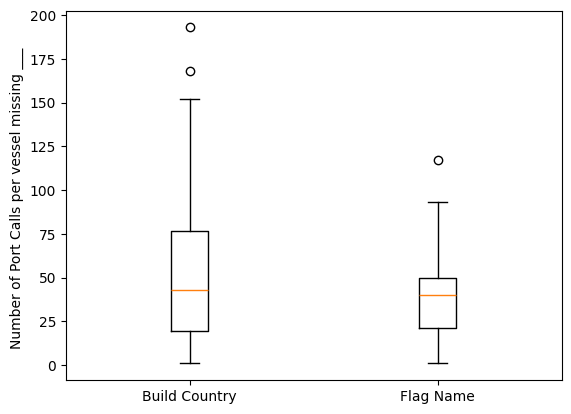

In [28]:
# Missing Build Country/Flag
# What is the distribution of number of port calls these vesels have
values_build = []
for _, row in missing_build_country.iterrows():
    matched_rows = port_calls[port_calls["vessel_id"] == row.id]
    values_build.append(len(matched_rows))


mean = np.mean(values_build)
median = np.median(values_build)
minimum = np.min(values_build)
maximum = np.max(values_build)
summation = np.sum(values_build)

print("Missing Build Country Number of Port Calls")
print(f"mean: {mean}")
print(f"median: {median}")
print(f"minimum: {minimum}")
print(f"maximum: {maximum}")
print(f"sum: {summation}")

values_flag = []
missing_flag = vessels[vessels["flag_name"].isnull()]
for _, row in missing_flag.iterrows():
    matched_rows = port_calls[port_calls["vessel_id"] == row.id]
    values_flag.append(len(matched_rows))

mean = np.mean(values_flag)
median = np.median(values_flag)
minimum = np.min(values_flag)
maximum = np.max(values_flag)
summation = np.sum(values_flag)


print("\n")
print("Missing Flag Name Number of Port Calls")
print(f"mean: {mean}")
print(f"median: {median}")
print(f"minimum: {minimum}")
print(f"maximum: {maximum}")
print(f"sum: {summation}")


plt.boxplot([values_build, values_flag], tick_labels=["Build Country", "Flag Name"])
plt.ylabel("Number of Port Calls per vessel missing ___ ")
plt.show()

Too much information in these to consider dropping them, will have to consider features that don't need these inputs

In [29]:
# 351 unmatched rows
cols_to_match_on = ["start_date_time", "end_date_time", "product", "product_family"]
unmatched = []
matches = 0
for _, row in missing_port_call_destination.iterrows():
    matched_rows = trades[trades["port_call_origin_id"] == row["port_call_origin_id"]]
    if len(matched_rows) > 1:  # Dont just count rows with no matches
        if all(matched_rows[cols_to_match_on] == row[cols_to_match_on]):
            pass
        else:
            unmatched.append((matched_rows))
    else:
        unmatched.append((matched_rows))

unmatched_df = pd.concat(unmatched, ignore_index=True)

In [30]:
unmatched_df

,id,port_call_origin_id,port_call_destination_id,traded_volume,distance,start_date_time,end_date_time,product,product_family
0,20706282,371277408,NaN,34819.0,NaN,2023-12-29 00:00:04,NaT,vacuum gasoil,dirty petroleum products
1,19522798,371077848,NaN,112625.0,NaN,2023-12-17 18:32:00,NaT,high sulfur fuel oil,dirty petroleum products
2,18621718,368974153,NaN,5244.0,NaN,2023-06-27 11:36:26,2023-08-08 03:04:58,palm oil,chem/bio
3,18666272,369000987,NaN,5244.0,NaN,2023-06-30 06:09:24,2023-08-08 03:04:58,palm oil mill effluent,chem/bio
4,18628271,369651136,NaN,75678.0,NaN,2023-09-10 17:24:55,NaT,ajapa,crude oil/condensate
...,...,...,...,...,...,...,...,...,...
346,20465225,370223263,NaN,4015.0,NaN,2023-10-21 01:36:00,2024-03-26 04:23:47,palm oil,chem/bio
347,20295034,370528320,NaN,10510.0,NaN,2023-11-01 01:26:17,2024-03-26 04:23:47,used cooking oil,chem/bio
348,19653652,370317931,NaN,4981.0,NaN,2023-10-30 14:07:00,2024-03-26 04:23:47,used cooking oil,chem/bio
349,17890096,368020577,NaN,5411.0,NaN,2023-04-26 07:11:00,2023-07-20 13:35:27,sunflower oil,chem/bio


On some manual inspection these could be the end of a run of journeys

In [31]:
hypothesis_works_for_rows = 0
failed_row_ids = []
for _, row in unmatched_df.iterrows():
    id = row.port_call_origin_id
    vessel_id = port_calls[port_calls.id == id]["vessel_id"].values[0]
    all_calls = port_calls[port_calls.vessel_id == vessel_id]
    if all_calls.iloc[-1].id == id:
        hypothesis_works_for_rows += 1
    else:
        failed_row_ids.append(row.id)
print(hypothesis_works_for_rows)

58


Clearly this isn't the solution to the problem, and these rows just have missing values

#### Final Data Cleaning Understanding

The data files have already been changed to using datetime objects. Missing values identified and their chosen outcome:

##### Port Calls
- end utc -> This won't affect model training as it is unlikely to be used in determining next port
- draught change -> This also won't be used in the model so again, we can keep columns with missing values
- lat/lon -> Removing the ~1000 port calls is only a small number of calls compared to the full dataset, but would mean losing information that would explain the full picture

##### Vessels
The only values likely to be dropped are the 25 without a flag name. This is only ~1000 port calls, however this depends on how linked flag name is to the next port

##### Trades
Due to being unable to explain the missing values for ~300 rows in this set, they will be dropped as being unable to track the destinations of these trade will likely affect model performance

In [32]:
# For Now only going to drop the ~300 rows
trades_cleaned = trades[~trades.id.isin(failed_row_ids)]

## Trend and Pattern Analysis

In [70]:
# First need to match trades up
trades_matched = trades_cleaned.merge(
    port_calls[
        [
            "id",
            "vessel_id",
            "start_utc",
            "end_utc",
            "destination",
            "destination_longitude",
            "destination_latitude",
        ]
    ],
    left_on="port_call_origin_id",
    right_on="id",
)
trades_matched = trades_matched.merge(
    port_calls[
        [
            "id",
            "vessel_id",
            "start_utc",
            "end_utc",
            "destination",
            "destination_longitude",
            "destination_latitude",
        ]
    ],
    left_on="port_call_destination_id",
    right_on="id",
    suffixes=("_orig", "_dest"),
)

In [71]:
# Basic Insights
print("Top 10 ports by call count:")
print(port_calls["destination"].value_counts().head(10))

# 2. Top trade routes
trades_matched["route"] = (
    trades_matched["destination_orig"] + " -> " + trades_matched["destination_dest"]
)
print("\nTop 10 trade routes:")
print(trades_matched["route"].value_counts().head(10))

Top 10 ports by call count:
destination
Singapore         12640
Rotterdam          8430
Ulsan              6114
Antwerp            5371
Houston            4825
Pelepas Light.     3199
Yeosu              2692
Zhoushan           2419
Lome Light.        2408
Daesan             2364
Name: count, dtype: int64

Top 10 trade routes:
route
Singapore -> Singapore              1685
Pelepas Light. -> Pelepas Light.    1369
Rotterdam -> Rotterdam               709
Daesan -> Incheon Port               681
Antwerp -> Antwerp                   637
Singapore -> Changi Airport          583
Ulsan -> Ulsan                       534
Torgovyy -> Kerch Light.             521
Houston -> Antwerp                   505
Saint John -> Portland (Maine)       489
Name: count, dtype: int64


A lot of these top trade routes are from a port to itself, so will likely cause a lot of model bias down the line. This is something we need to be careful of

In [72]:
# Check association between vessel type and cargo type
trade_vessel = trades_cleaned.merge(
    port_calls[["id", "vessel_id"]], left_on="port_call_origin_id", right_on="id"
)
trade_vessel = trade_vessel.merge(
    vessels[["id", "vessel_type"]], left_on="vessel_id", right_on="id"
)

print("Count of each vessel type")
for vessel_type in trade_vessel["vessel_type"].unique():
    print(f"{vessel_type} : {len(trade_vessel[trade_vessel['vessel_type'] == vessel_type])}")

Count of each vessel type
Chemical/Oil Products Tanker : 63988
Crude/Oil Products Tanker : 94934
Chemical Tanker : 2874
Products Tanker  : 37305
Crude Oil Tanker : 20673
Asphalt/Bitumen Tanker : 7939
FSO, Oil : 9
Ore/Oil Carrier : 95
Bulk/Caustic Soda Carrier (CABU) : 93
Offshore Tug/Supply Ship : 5
Bulk/Oil Carrier (OBO) : 33
Bulk Carrier : 26
LNG Tanker : 2


In [73]:
print("Association between Vessel Type and Product Family:")
pd.crosstab(trade_vessel["vessel_type"], trade_vessel["product_family"])

Association between Vessel Type and Product Family:


product_family,ammonia,chem/bio,clean petroleum products,coal,crude oil/condensate,dirty petroleum products,grains/oilseeds,iron ore,lng,lpg,minor bulks,olefins
vessel_type,,,,,,,,,,,,
Asphalt/Bitumen Tanker,0,71,214,0,3,7651,0,0,0,0,0,0
Bulk Carrier,0,0,14,0,2,0,8,0,0,0,2,0
Bulk/Caustic Soda Carrier (CABU),0,73,0,12,0,0,0,1,0,0,7,0
Bulk/Oil Carrier (OBO),0,13,15,0,0,0,5,0,0,0,0,0
Chemical Tanker,0,1790,1078,0,2,4,0,0,0,0,0,0
Chemical/Oil Products Tanker,0,37509,22139,2,377,3947,1,0,0,0,12,1
Crude Oil Tanker,0,151,2793,0,14083,3644,0,0,0,0,2,0
Crude/Oil Products Tanker,3,25728,39211,2,17023,12950,3,0,0,7,2,5
"FSO, Oil",0,3,0,0,5,1,0,0,0,0,0,0


There will likely be some issues with predictions of some of the vessel types with low count - Assuming they do different routes

Need a comparison of these different reigions

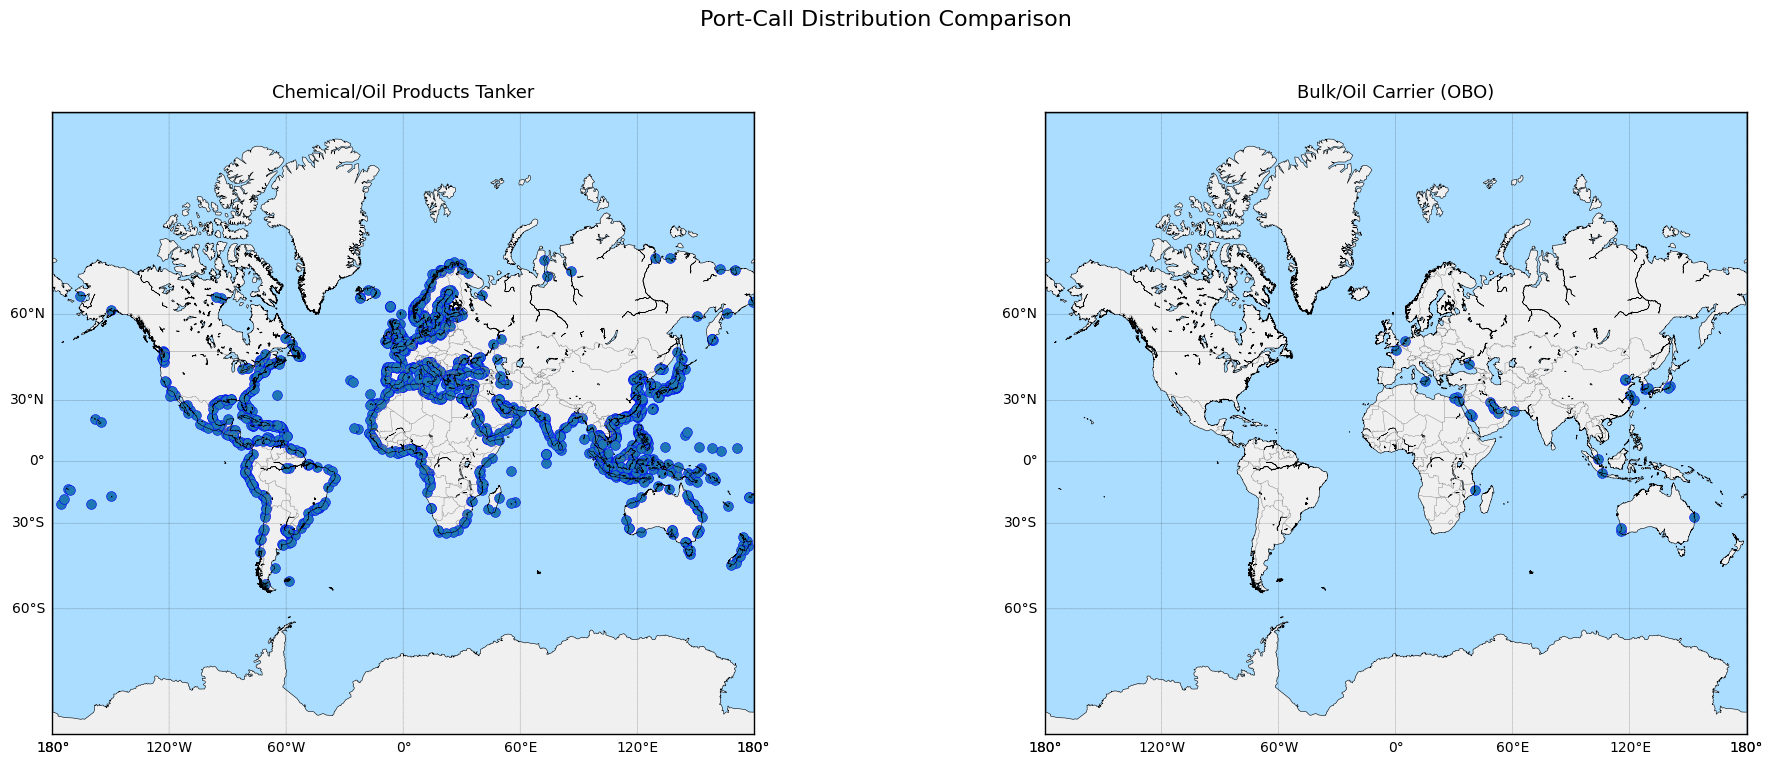

In [74]:
VESSEL_TYPES = ['Chemical/Oil Products Tanker', 'Bulk/Oil Carrier (OBO)']

calls = (
    port_calls
    .merge(vessels[['id', 'vessel_type', 'flag_name']], left_on='vessel_id', right_on='id', how='left')
    .dropna(subset=['destination_longitude', 'destination_latitude', 'vessel_type'])
)
calls['vessel_type'] = calls['vessel_type'].str.strip()

def draw_map(ax, df, title):
    m = Basemap(
        ax=ax, projection='merc', resolution='l',
        llcrnrlat=-80, urcrnrlat=85,
        llcrnrlon=-180, urcrnrlon=180,
        lat_ts=20,
    )
    m.drawcoastlines(linewidth=0.4)
    m.drawcountries(linewidth=0.3, color='gray')
    m.fillcontinents(color='#f0f0f0', lake_color='#aaddff')
    m.drawmapboundary(fill_color='#aaddff')
    m.drawparallels(np.arange(-90,  91, 30), labels=[1, 0, 0, 0], linewidth=0.2)
    m.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.2)

    pts = df.drop_duplicates(subset=['destination_longitude', 'destination_latitude'])
    x, y = m(pts['destination_longitude'].values, pts['destination_latitude'].values)
    m.scatter(x, y, s=50, alpha=1, edgecolors='b', linewidths=0.4)
    ax.set_title(title, fontsize=13, pad=10)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, vtype in zip(axes, VESSEL_TYPES):
    draw_map(ax, calls[calls['vessel_type'] == vtype], vtype)

fig.suptitle('Port-Call Distribution Comparison', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Larger Vessel Categories are spread across the world whereas a category like 'Bulk/Oil Carrier (OBO)' is focused on areas in the east. This further cements concerns around handling these smaller vessel types - It could be worth creating an other category for the purpose of a smaller prototype model and expanding as more data is gathered on these other vessel types

Now look at how the flown flag affects the locations

In [75]:
vessels["flag_name"].value_counts()

flag_name
Marshall Islands                           1302
Liberia                                    1221
Panama                                     1188
Singapore                                   496
Malta                                       495
                                           ... 
Samoa                                         1
Korea (Democratic People's Republic of)       1
Niue                                          1
Faroe Islands                                 1
Papua New Guinea                              1
Name: count, Length: 98, dtype: int64

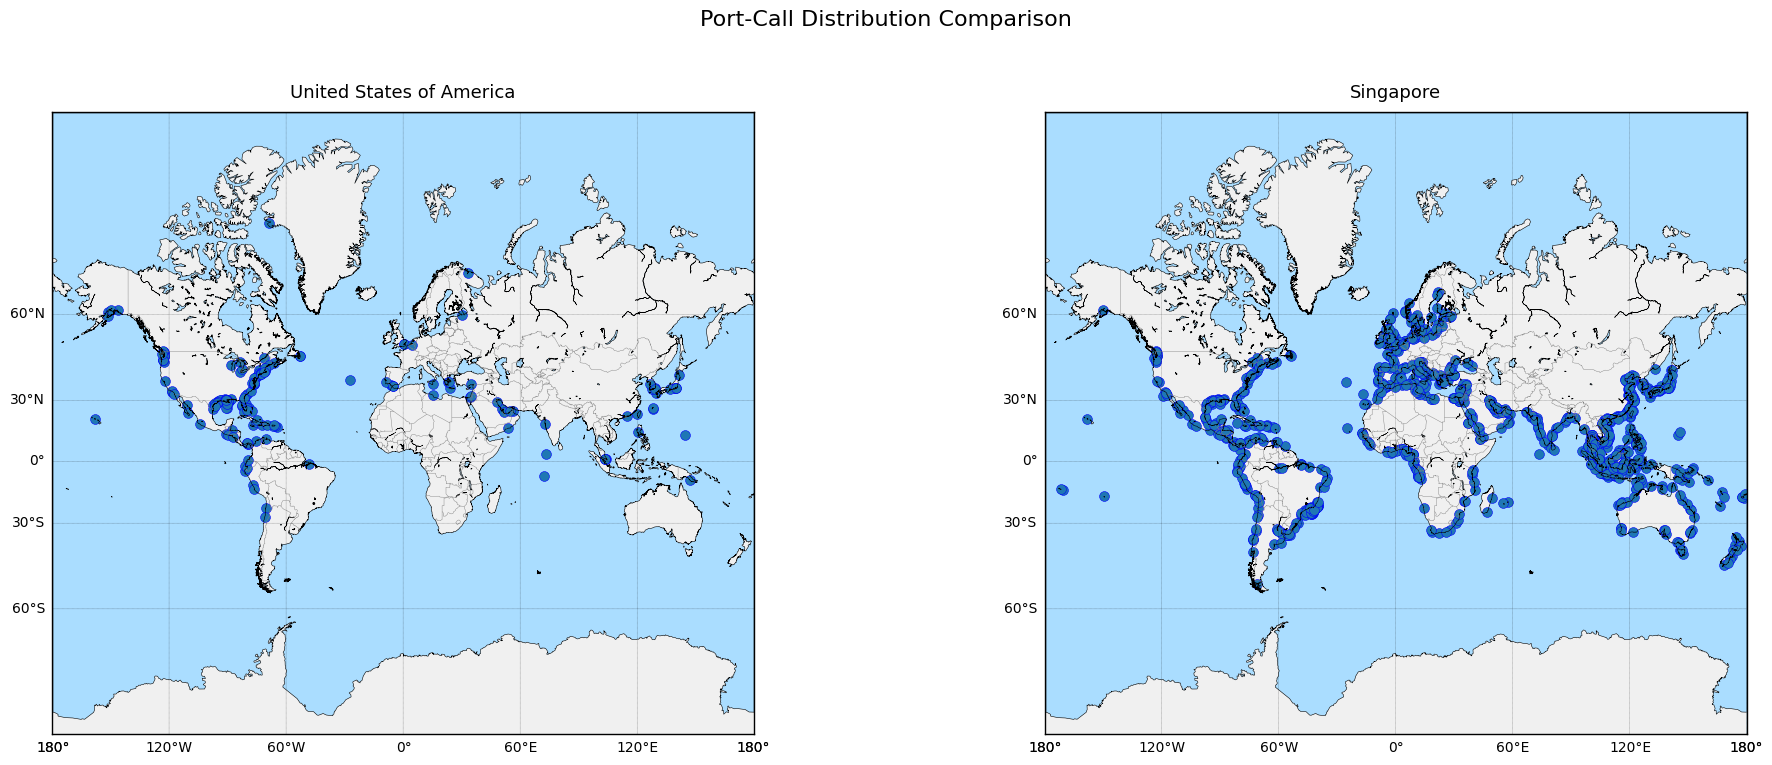

In [76]:
VESSEL_FLAGS = ['United States of America', 'Singapore']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, vtype in zip(axes, VESSEL_FLAGS):
    draw_map(ax, calls[calls['flag_name'] == vtype], vtype)

fig.suptitle('Port-Call Distribution Comparison', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Although both of these countries flags operate worldwide, there is a clear density difference, in that USA vessels more often stop in the US whilst Singapore Vessels stop more in East Asia

We can also look separately at the distribution of repeated ports within a vessel. This tells us if vessels frequent the same ports as a high proportion of their total visits

Vessel port loyalty statistics:
count    8901.000000
mean        0.270145
std         0.179959
min         0.034483
25%         0.148148
50%         0.214286
75%         0.337838
max         1.000000
Name: loyalty_ratio, dtype: float64


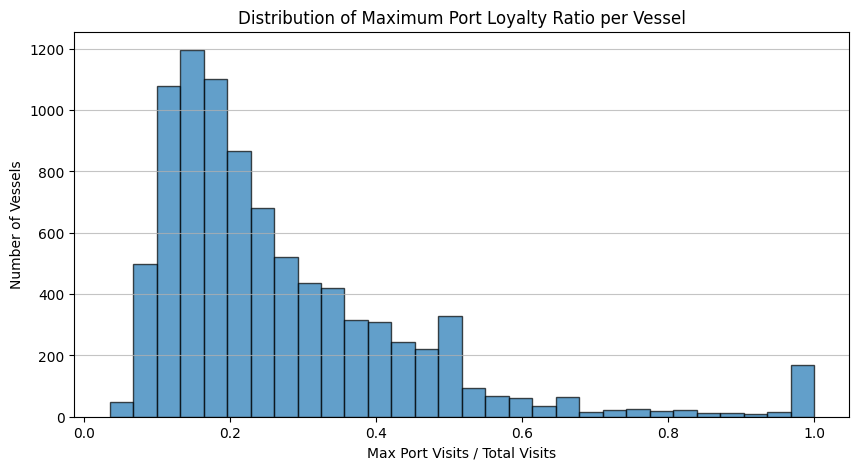

In [77]:
vessel_port_visits = (
    port_calls.groupby(["vessel_id", "destination"]).size().reset_index(name="visits")
)
vessel_totals = port_calls.groupby("vessel_id").size().reset_index(name="total")
loyalty_df = vessel_port_visits.merge(vessel_totals, on="vessel_id")
loyalty_df["loyalty_ratio"] = loyalty_df["visits"] / loyalty_df["total"]
max_loyalty_per_vessel = loyalty_df.groupby("vessel_id")["loyalty_ratio"].max()

print("Vessel port loyalty statistics:")
print(max_loyalty_per_vessel.describe())

plt.figure(figsize=(10, 5))
plt.hist(max_loyalty_per_vessel, bins=30, edgecolor="black", alpha=0.7)
plt.title("Distribution of Maximum Port Loyalty Ratio per Vessel")
plt.xlabel("Max Port Visits / Total Visits")
plt.ylabel("Number of Vessels")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [78]:
loyalty_df

,vessel_id,destination,visits,total,loyalty_ratio
0,56709,Beaumont/Port Arthur,1,28,0.035714
1,56709,Galveston Industrial Port,1,28,0.035714
2,56709,Houston,12,28,0.428571
3,56709,Texas City,14,28,0.500000
4,56751,Beaumont/Port Arthur,2,31,0.064516
...,...,...,...,...,...
131479,121319,Ulsan,3,50,0.060000
131480,121319,Xiamen,1,50,0.020000
131481,121319,Zhapu,1,50,0.020000
131482,121319,Zhu Hai,1,50,0.020000


Analysis of the graph and dataframe show 3 major peaks within the data. The first at around 0.15, the second at 0.5 and the final at 1. The ports at the 0.15 mark seem to be routine pickup spots. Those at the 0.5 seem to be a home port, or where a product is delivered to. The peak at 1 indicates a vessel is only moving between the same port.

This indicates ports should be able to be classified into sending or recieving categories.

In [79]:
# Trade -> origin_id, destination_id
# corresponding port_call -> destination IS WHERE VESSEL IS not where it will head to

In [ ]:
BOUNDARY_MIN = 0
BOUNDARY_LQ = 0.25
BOUNDARY_UQ = 0.75
BOUNDARY_MAX = 1


# Unique port call ids for all trades - means we only count multiple trades with the same id once
origin_ids = set(trades_cleaned["port_call_origin_id"].dropna())
dest_ids = set(trades_cleaned["port_call_destination_id"].dropna())

# Go through all the port calls to find ones that align with the origins and desinations
port_calls["is_trade_origin"] = port_calls["id"].isin(origin_ids).astype(int)
port_calls["is_trade_dest"] = port_calls["id"].isin(dest_ids).astype(int)

# How many were found
print(f"Port calls that were a trade origin: {port_calls['is_trade_origin'].sum():,}")
print(f"Port calls that were a trade destination: {port_calls['is_trade_dest'].sum():,}")
print(f"Port calls with no trade role: {(~port_calls['id'].isin(origin_ids | dest_ids)).sum():,}")

ports = (
    port_calls.groupby("destination")
    .agg(
        total_calls=("id", "count"),
        trade_origins=("is_trade_origin", "sum"),
        trade_dests=("is_trade_dest", "sum"),
        avg_cargo_volume=("cargo_volume", "mean"),
        lat=("destination_latitude", "first"),
        lon=("destination_longitude", "first")
    )
    .reset_index()
)

ports["total_trades"] = ports["trade_origins"] + ports["trade_dests"]

# Sending ratio: 1.0 = just sending, 0.0 = just receiving
ports["sending_ratio"] = np.where(
    ports["total_trades"] > 0,  # cond
    ports["trade_origins"] / ports["total_trades"],  # true
    np.nan  # false
)

ports["port_type"] = pd.cut(
    ports["sending_ratio"],  # column to apply
    bins=[BOUNDARY_MIN, BOUNDARY_LQ, BOUNDARY_UQ, BOUNDARY_MAX],  # boundries
    labels=["receiving", "mixed", "sending"],  # boundry labels
    include_lowest=True  # min boundary is in first boundry
)

ports = ports.sort_values("total_calls", ascending=False)

print("\n")
print(ports["port_type"].value_counts())
print("\n")

cols = ["destination", "total_calls", "trade_origins", "trade_dests", "sending_ratio"]
for label in ["sending", "receiving", "mixed"]:
    print(f"Top 15 {label} by total trades")
    print(
        ports[ports["port_type"] == label]
        .nlargest(15, "total_calls")[cols]
        .to_string(index=False)
    )
    print()

Port calls that were a trade origin: 154,865
Port calls that were a trade destination: 170,898
Port calls with no trade role: 21,515


port_type
receiving    961
sending      557
mixed        493
Name: count, dtype: int64


Top 15 sending by total trades
           destination  total_calls  trade_origins  trade_dests  sending_ratio
               Houston         4825           3702         1036       0.781342
                Daesan         2364           1831          529       0.775847
                 Dumai         2242           2086          139       0.937528
Jubail Industrial Port         2095           1941          141       0.932277
            Ras Tanura         1978           1804          169       0.914344
        Corpus Christi         1884           1675          207       0.890011
                 Yanbu         1684           1344          298       0.818514
          Novorossiysk         1663           1643           14       0.991551
        Mina Al-Ahmadi         127

We can validate this through some research into some of these ports

Novorossiysk is known to be Russia's biggest export port, so it having a 99.2% sending ratio aligns

New York is also known to be a large import port and so again aligns with with 90.2% import ratio

We can now look at patterns between vessels going to import ports after going to export ones

In [91]:
port_calls

,id,vessel_id,start_utc,end_utc,cargo_volume,draught_change,destination,destination_longitude,destination_latitude,is_trade_origin,is_trade_dest
0,366999220,74064,2023-01-01 00:00:36,2023-01-01 16:02:18,111617,5.5,Novorossiysk,37.813008,44.718040,1,0
1,366974831,70585,2023-01-01 00:00:48,2023-01-01 15:16:55,0,-0.2,Singapore,103.745613,1.234135,0,1
2,367187709,90771,2023-01-01 00:01:00,2023-01-03 00:00:00,0,-5.5,Philadelphia,-75.229059,39.949923,0,1
3,366902380,86336,2023-01-01 00:02:19,2023-01-03 13:37:40,0,-4.7,Sao Luis,-44.380646,-2.605307,0,1
4,366971646,105430,2023-01-01 00:02:57,2023-01-02 01:31:40,0,-2.0,Ulsan,129.332479,35.479874,0,1
...,...,...,...,...,...,...,...,...,...,...,...
347272,371325310,72072,2023-12-31 23:56:57,2024-01-01 03:37:33,6845,NaN,Kerch Light.,36.565590,45.105042,1,0
347273,371325316,72072,2023-12-31 23:56:58,2024-01-01 03:28:16,11051,NaN,Kerch Light.,36.565590,45.105042,1,0
347274,371325311,115665,2023-12-31 23:56:58,2024-01-01 03:37:33,0,NaN,Kerch Light.,36.565590,45.105042,0,1
347275,371325308,73804,2023-12-31 23:59:24,2024-01-05 08:01:23,0,-4.9,Kalamata Light.,22.073930,36.865067,0,1


In [ ]:
# Get all routes
pairs = {}
for i in range(1, 5):
    for j in range(1, 5):
        pairs[str(i) + str(j)] = 0

port_calls.sort_values("start_utc", ascending=True, inplace=True)
for vessel_id in port_calls["vessel_id"].unique():
    journey = port_calls[port_calls['vessel_id'] == vessel_id]
    port_type = -1
    for i, journey_row in journey.iterrows():
        if port_type == -1:
            # if other type == 1, origin == 2, if dest == 3, both =4
            port_type = 1 + journey_row["is_trade_origin"] + (2 * journey_row["is_trade_dest"])
        else:
            next_port_type = 1 + journey_row["is_trade_origin"] + (2 * journey_row["is_trade_dest"])
            key = str(port_type)+str(next_port_type)
            pairs[key] = pairs[key] + 1

In [96]:
pairs

{'11': 4824,
 '12': 6922,
 '13': 8133,
 '14': 0,
 '21': 8136,
 '22': 73906,
 '23': 80715,
 '24': 1,
 '31': 7806,
 '32': 69913,
 '33': 78020,
 '34': 0,
 '41': 0,
 '42': 0,
 '43': 0,
 '44': 0}

We are seeing the largest proportion of these journeys go from an origin port (2) to a destination port (3) which is as expected
There is also high numbers of journeys between ports of the same types. This was expected as a vessel may pickup more cargo, or deliver more cargo. When used as an input feature, the vessels cargo volume should be included

The other combination of 3 (destination/import) to 2 (origin/export) is vessels going back to pick up goods, so again paired with cargo volume should be a good predictor

The only risk for this is that the port classification is derived from the data which could bleed information from training to testing data. We can avoid this by regenerating these insights on just our training set, which we need to derive carefully.